## HỒI QUY TUYẾN TÍNH
#### Tập dữ liệu: house_price.csv
#### Gồm các cột:
*  area (diện tích, m²)
*   bedrooms (số phòng ngủ)
*   age (tuổi ngôi nhà, năm)
*   price (giá bán, triệu đồng)
#### Yêu cầu:
1.  Đọc dữ liệu, hiển thị 5 dòng đầu tiên.
2.  Huấn luyện mô hình hồi quy tuyến tính dự đoán price dựa trên 3 đặc trưng còn lại.
3.  In ra hệ số hồi quy và sai số RMSE.
4.  Vẽ biểu đồ so sánh giá dự đoán và giá thực tế.


In [61]:
import pandas as pd

In [62]:
df = pd.read_csv("data/house_price.csv")
df.head()

,area,bedrooms,age,price
0,152,1,23,264.819479
1,229,4,8,487.574342
2,142,1,20,318.743326
3,64,1,16,163.749881
4,156,2,13,361.723595


In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
X = df[["area", "bedrooms","age"]]
y = df["price"]
model = LinearRegression()
model.fit(X,y)
y_pred = model.predict(X)


In [64]:
rmse = np.sqrt(mean_absolute_error(y,y_pred))
print("Hệ số hồi quy:", model.coef_)
print("Hệ số chặn:",model.intercept_)
print("RMSE:",rmse)

Hệ số hồi quy: [ 1.99520019 10.2160508  -3.05598631]
Hệ số chặn: 50.16489476749382
RMSE: 4.872346285257314


model.coef là vector hệ số hồi quy cho biết mức độ thay đổi trung bình của biến price khi các biến độc lập thay đổi

-> Hệ số hồi quy: [ 1.99520019 10.2160508  -3.05598631]

Tức là khi diện tích tăng 1m thì giá tăng là 1,99 triệu, phòng tăng thêm 1 phòng thì giá tăng thêm 10 triệu, và độ tuổi của nhà càng lớn thì giá nhà càng giảm

model.intercept_ là giá trị trung bình của price khi các biến độc lập bằng 0 
-> giá trị nhà là 50 triệu

RMSE (Root Mean Square Error) là độ lệch trung bình giữa giá trị thực và giá trị dự đoán

RMSE càng nhỏ -> mô hình càng khớp dữ liệu tốt

RMSE > 100 nghĩa là sai số lớn

RMSE < 30 thường được xem là ổn

Ở đây, RMSE: 4.872346285257314 -> chứng tỏ mô hình dự đoán ít sai lệch

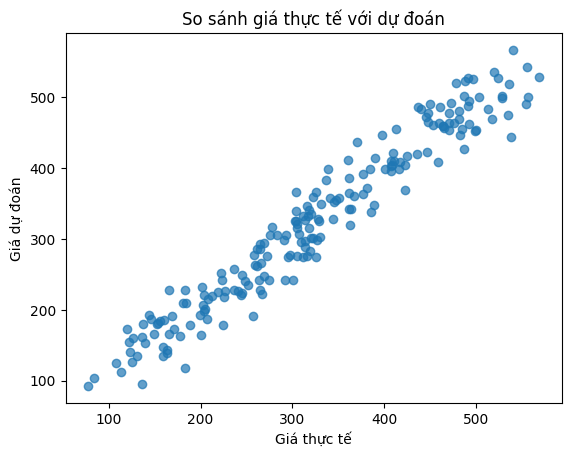

In [65]:
plt.scatter(y,y_pred,alpha=0.7)
plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.title("So sánh giá thực tế với dự đoán")
plt.show()

các điểm nằm gần đường chéo 45 độ -> mô hình dự đoán chính xác

## HỒI QUY DÙNG OLS
### Phân tích mối quan hệ giũa chi tiêu quảng cáo và doanh số bán hàng
#### Một công ty muốn đánh giá mức độ ảnh hưởng của ngân sách quảng cáo đến doanh số bán hàng

In [66]:
# 1. Xây dựng mô hình hồi quy bằng OLS
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
# df = pd.read_csv("data")

## HỒI QUY LOGISTIC

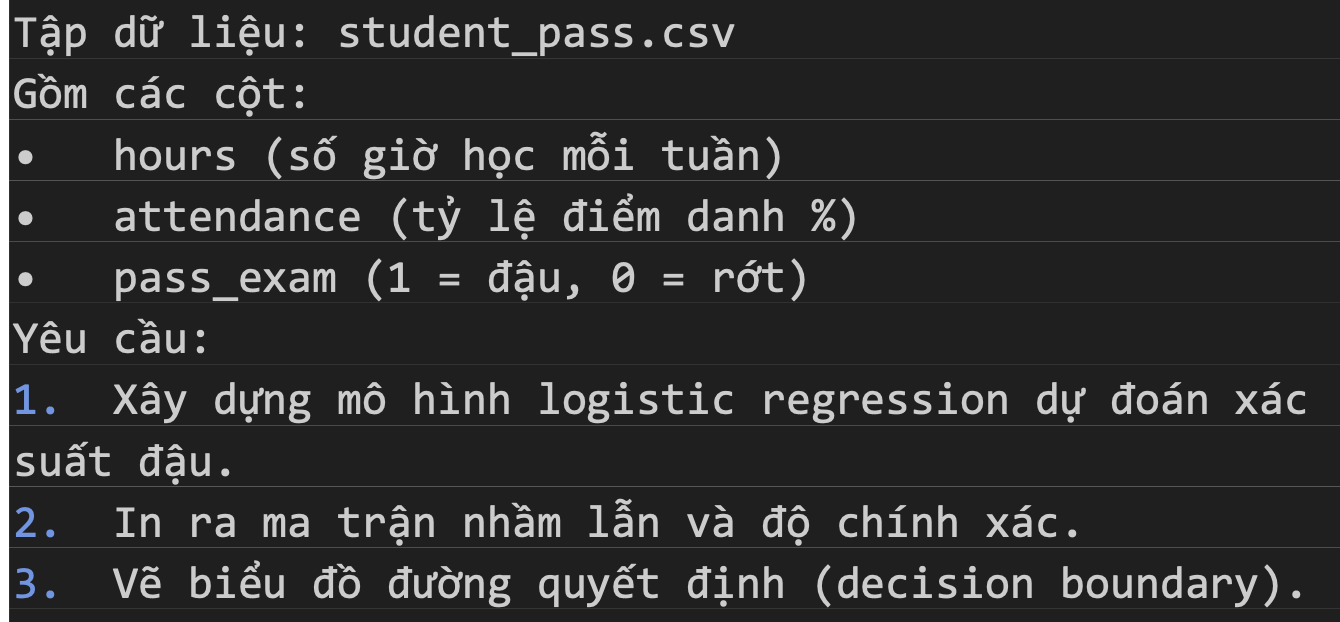

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score
import seaborn as sns
df = pd.read_csv("data/student_pass.csv")
X = df[["hours","attendance"]]
y = df['pass_exam']
model = LogisticRegression()
model.fit(X,y)
y_pred = model.predict(X)

In [68]:
print("Độ chính xác: ", accuracy_score(y,y_pred))
print("Ma trận nhầm lẫn: \n",confusion_matrix(y,y_pred))


Độ chính xác:  0.64
Ma trận nhầm lẫn: 
 [[52 26]
 [28 44]]


Độ chính xác chỉ khoảng 0.64 -> mô hình dự đoán chưa tốt
Ma trận nhầm lẫn:
* 52: Số sinh viên đậu dự đoán đúng
* 44: số sinh viên rớt dự đoán đúng
* 26 sinh viên đậu nhưng thực tế 26 sinh viên này rớt 
* và 28 là số dự đoán sai của tỷ lệ rớt nhưng thực tế lại đậu 

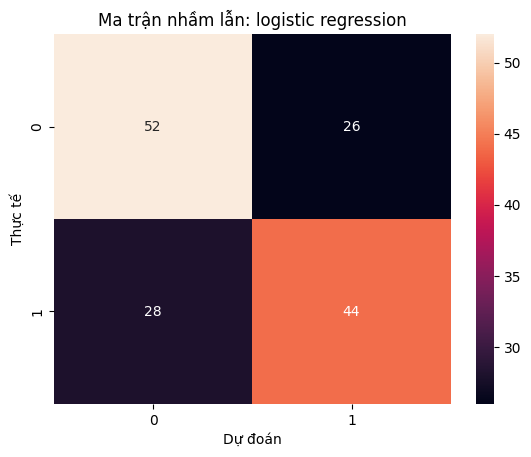

In [69]:
sns.heatmap(confusion_matrix(y,y_pred),annot=True,fmt="d")
plt.title("Ma trận nhầm lẫn: logistic regression")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.show()

## PHÂN CỤM K-MEANS

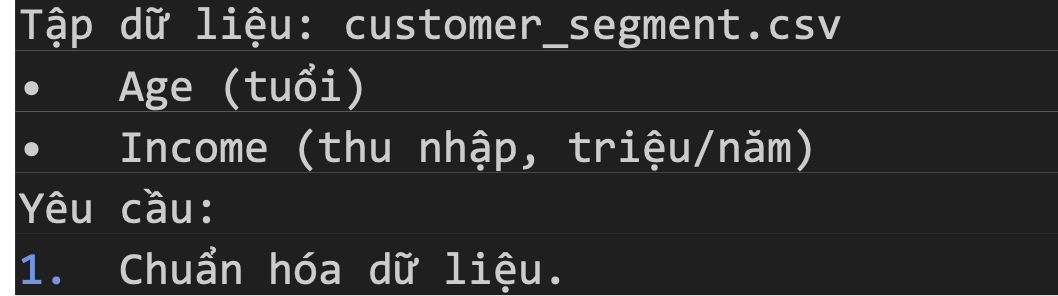

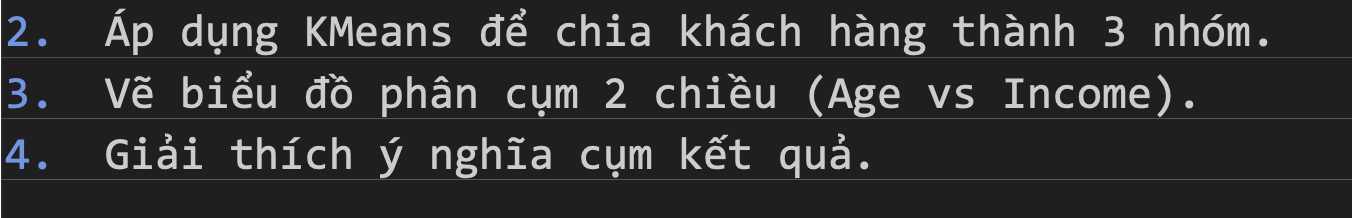

In [70]:
from sklearn.cluster import KMeans

### K-Means với `customer_segment.csv` (theo đề bài)
- Chuẩn hóa dữ liệu `Age`, `Income`.
- Áp dụng KMeans với K=3.
- Vẽ scatter 2D Age vs Income theo màu cụm.
- Diễn giải cụm dựa trên tâm cụm.


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Đọc dữ liệu
cust = pd.read_csv('data/customer_segment.csv')
cust.head()


,Age,Income
0,20,51
1,57,274
2,51,338
3,57,282
4,44,463


In [72]:
# Chuẩn hóa
features = ['Age', 'Income']
scaler = StandardScaler()
X_std = scaler.fit_transform(cust[features])

# KMeans K=3
kmeans3 = KMeans(n_clusters=3, n_init=10, random_state=42)
labels = kmeans3.fit_predict(X_std)
centroids_std = kmeans3.cluster_centers_

# Gắn nhãn vào dataframe
cust['cluster'] = labels

print('Số mẫu mỗi cụm:')
print(cust['cluster'].value_counts().sort_index())
print('\nTâm cụm (chuẩn hóa):')
print(centroids_std)

# Chuyển tâm cụm về thang đo gốc
centroids_orig = scaler.inverse_transform(centroids_std)
print('\nTâm cụm (thang đo gốc Age, Income):')
print(centroids_orig)


Số mẫu mỗi cụm:
cluster
0    70
1    67
2    63
Name: count, dtype: int64

Tâm cụm (chuẩn hóa):
[[ 1.00762015  0.32880738]
 [-0.79616935  0.76140486]
 [-0.27285816 -1.17508956]]

Tâm cụm (thang đo gốc Age, Income):
[[ 50.57142857 328.07142857]
 [ 30.13432836 386.79104478]
 [ 36.06349206 123.93650794]]


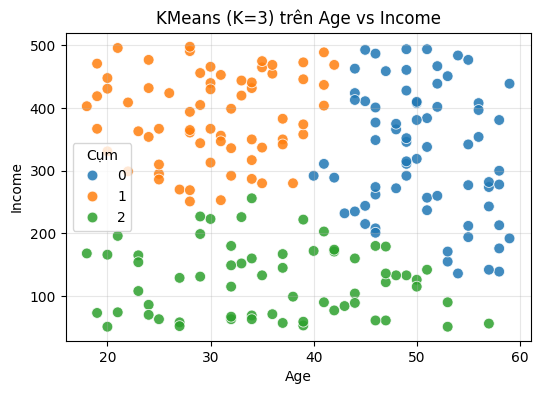

Đã lưu: data/customer_segment_labeled.csv


In [73]:
# Vẽ scatter 2D Age vs Income theo cụm và lưu kết quả
palette = sns.color_palette('tab10', 3)
plt.figure(figsize=(6, 4))
sns.scatterplot(data=cust, x='Age', y='Income', hue='cluster', palette=palette, s=60, alpha=0.85)
plt.title('KMeans (K=3) trên Age vs Income')
plt.legend(title='Cụm')
plt.grid(True, alpha=0.3)
plt.show()

# Lưu kết quả có nhãn
cust.to_csv('data/customer_segment_labeled.csv', index=False)
print('Đã lưu: data/customer_segment_labeled.csv')



- Cụm 0: Tuổi trẻ, thu nhập thấp → nhóm mới đi làm.
- Cụm 1: Tuổi trung niên, thu nhập cao → khách hàng ổn định, tiềm năng.
- Cụm 2: Tuổi lớn, thu nhập trung bình → nhóm sắp/đang ổn định tài chính.
Dựa vào tâm cụm (thang đo gốc) để mô tả “chân dung” từng nhóm, từ đó đề xuất chiến lược marketing phù hợp.


## LUẬT KẾT HỢP (Association Rules – Apriori)
Tập dữ liệu: `transactions.csv`
- Đọc dữ liệu giỏ hàng và mã hóa dạng giao dịch.
- Tìm tập mục thường xuyên với `min_support=0.3`.
- Sinh luật với `min_confidence=0.6`, in top 5 luật mạnh nhất theo lift.


In [74]:
pip install mlxtend


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [75]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# 1) Đọc dữ liệu giao dịch
df_tx = pd.read_csv('data/transactions.csv', header=None, names=['Items'])
transactions = df_tx['Items'].dropna().apply(lambda x: [i.strip() for i in str(x).split(',')]).tolist()

# 2) Mã hóa dạng one-hot
t_encoder = TransactionEncoder()
X = t_encoder.fit(transactions).transform(transactions)
df_basket = pd.DataFrame(X, columns=t_encoder.columns_)

# 3) Tập mục thường xuyên
freq_items = apriori(df_basket, min_support=0.3, use_colnames=True).sort_values('support', ascending=False)
print('=== TẬP MỤC THƯỜNG XUYÊN ===')
print(freq_items.head(15))

# 4) Sinh luật
rules = association_rules(freq_items, metric='confidence', min_threshold=0.6)
rules = rules.sort_values(['lift','confidence','support'], ascending=False)
print('\n=== TOP 5 LUẬT ===')
print(rules[['antecedents','consequents','support','confidence','lift']].head(5))


=== TẬP MỤC THƯỜNG XUYÊN ===
    support  itemsets
7  0.405941    (milk)
1  0.386139  (banana)
2  0.386139    (beer)
5  0.356436  (cheese)
4  0.346535  (butter)
0  0.336634   (apple)
3  0.316832   (bread)
6  0.316832  (coffee)

=== TOP 5 LUẬT ===
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


## PHÂN TÍCH NHÂN TỐ CHÍNH (PCA)
Tập dữ liệu: `iris_pca.csv`
- Chuẩn hóa 4 đặc trưng đầu.
- Giảm chiều xuống 2 thành phần chính.
- Vẽ scatter 2D, màu theo `species`.
- In tỷ lệ phương sai giải thích.


Tỷ lệ phương sai giải thích: [0.72962445 0.22850762]


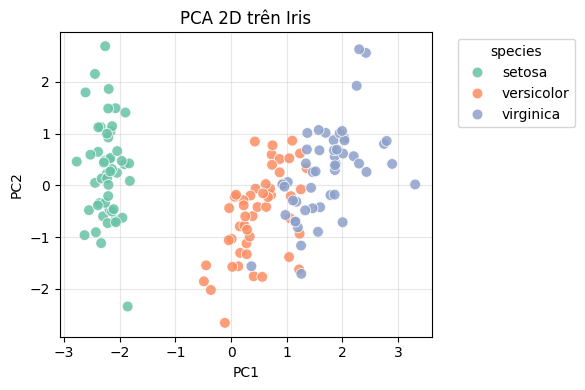

In [76]:
# PCA (sửa cột theo file iris_pca.csv)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = pd.read_csv('data/iris_pca.csv')
# Cột thực tế trong file
cols = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
if set(cols).issubset(iris.columns):
    features = cols
else:
    features = iris.select_dtypes(include=[np.number]).columns[:4].tolist()

X = iris[features].values
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)
print('Tỷ lệ phương sai giải thích:', pca.explained_variance_ratio_)

# Lấy nhãn species từ cột target nếu có
if 'target' in iris.columns:
    species = iris['target'].map({0:'setosa',1:'versicolor',2:'virginica'})
else:
    species = iris.get('species', pd.Series(['NA']*len(iris)))

plt.figure(figsize=(6,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=species, palette='Set2', s=60, alpha=0.85)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D trên Iris')
plt.grid(True, alpha=0.3)
plt.legend(title='species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## CÂY QUYẾT ĐỊNH (Decision Tree)
Tập dữ liệu: `loan_data.csv`
- Dự đoán `Default`.
- In độ chính xác và ma trận nhầm lẫn.
- Vẽ cây quyết định và hiển thị mức độ quan trọng đặc trưng.


Accuracy: 0.7
Confusion matrix:
 [[25  3]
 [ 9  3]]


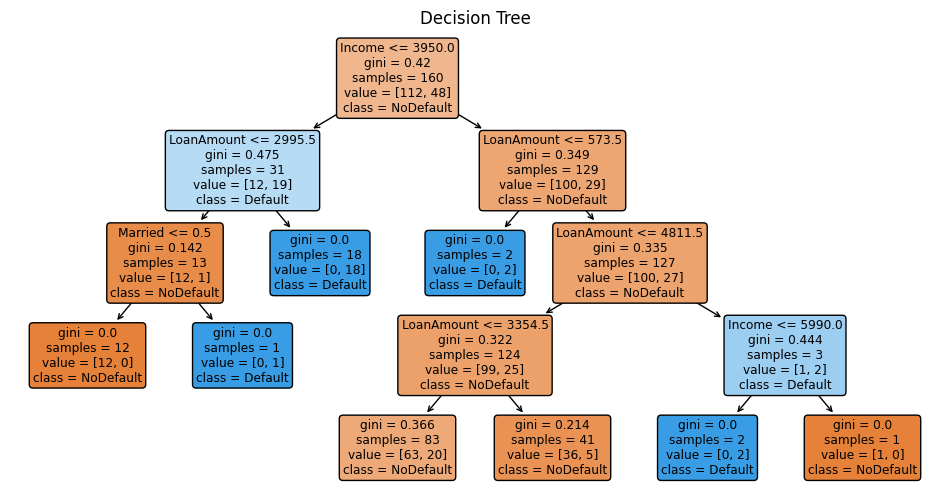


Feature importance:
LoanAmount    0.618343
Income        0.315860
Married       0.065798
Age           0.000000
dtype: float64


In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

# 1) Đọc dữ liệu
loan = pd.read_csv('data/loan_data.csv')

# 2) Tiền xử lý biến phân loại
if 'Married' in loan.columns:
    loan['Married'] = loan['Married'].map({'Yes':1, 'No':0}).fillna(0).astype(int)

features = [c for c in loan.columns if c != 'Default']
X = loan[features]
y = loan['Default']

# 3) Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4) Huấn luyện
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# 5) Đánh giá
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print('Accuracy:', round(acc, 4))
print('Confusion matrix:\n', cm)

# 6) Vẽ cây
plt.figure(figsize=(12,6))
plot_tree(clf, feature_names=features, class_names=['NoDefault','Default'], filled=True, rounded=True, proportion=False)
plt.title('Decision Tree')
plt.show()

# 7) Tầm quan trọng đặc trưng
fi = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
print('\nFeature importance:')
print(fi.head(10))
